# Experimento Paper Chunking QASPER

El proyecto parte del paper:

> **Qu, Tu y Bao (2025), “Is Semantic Chunking Worth the Computational Cost?”**

Nuestro experimento es una **replicación parcial y una extensión**. No intentamos reproducir todos los datasets ni todas las tareas del artículo original.

## Pregunta que queremos responder

> **¿Qué estrategia de chunking ofrece una mejor relación entre calidad de recuperación y costo computacional en documentos científicos?**

Comparamos tres alternativas bajo el mismo pipeline:

1. **Fixed-size chunking** — baseline simple.
2. **Semantic breakpoint chunking** — corta cuando cambia fuertemente el significado entre oraciones consecutivas.
3. **Structure-aware chunking** — propuesta ligera que aprovecha la estructura de párrafos del documento.

Medimos **Precision, Recall y F1**, junto con **tiempo, cantidad de chunks y tokens procesados**.


## 1. Instalación y configuración

Usamos herramientas relativamente ligeras para que el experimento pueda ejecutarse en Colab sin requerir una GPU grande.

El modelo de embeddings por defecto es `all-MiniLM-L6-v2`. Es más pequeño que los modelos principales evaluados en el paper base, por lo que **nuestros números no deben compararse directamente con los números absolutos del artículo original**. Lo importante es comparar las tres estrategias bajo las mismas condiciones.

In [1]:
!pip -q install datasets sentence-transformers spacy rapidfuzz pandas numpy matplotlib ipywidgets



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import sys
import time
import random
import re
import json
import shutil
import warnings
import logging
from dataclasses import dataclass
from collections import defaultdict
from pathlib import Path
from typing import List, Dict, Any, Iterable, Tuple

os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
warnings.filterwarnings("ignore", message="IProgress not found.*")
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from rapidfuzz import fuzz
import spacy

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

#DEMO_MODE = True
DEMO_MODE = False

N_DOCS = 20 if DEMO_MODE else 100
MAX_QUESTIONS = 40 if DEMO_MODE else 250

SPLIT = "validation"
#MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
MODEL_NAME = "sentence-transformers/all-mpnet-base-v2"

TOP_K_VALUES = [1, 3, 5, 10]

FIXED_CHUNK_SIZE = 6
FIXED_OVERLAP = 1

SEMANTIC_TARGET_CHUNKS = 8

STRUCTURE_MAX_SENTENCES = 8
STRUCTURE_OVERLAP = 1

print("DEMO_MODE:", DEMO_MODE)
print("N_DOCS:", N_DOCS)
print("MAX_QUESTIONS:", MAX_QUESTIONS)
print("MODEL_NAME:", MODEL_NAME)


DEMO_MODE: False
N_DOCS: 100
MAX_QUESTIONS: 250
MODEL_NAME: sentence-transformers/all-mpnet-base-v2


## 2. Carga de QASPER

QASPER está disponible en Hugging Face, pero su repositorio principal todavía contiene un script de carga antiguo (`qasper.py`). Las versiones recientes de la librería `datasets` ya no ejecutan este tipo de scripts.

Para mantener el notebook compatible con Colab actual, cargamos directamente la **conversión oficial a Parquet publicada por Hugging Face**. Los datos siguen siendo QASPER; solamente cambia el mecanismo de lectura.

Primero cargamos el dataset y miramos cómo viene estructurado antes de hacer cualquier transformación.


In [3]:
# QASPER conserva un script antiguo en el repositorio principal.
# Las versiones recientes de `datasets` ya no ejecutan scripts de datasets.
# Por eso cargamos directamente la conversión oficial a Parquet de Hugging Face.

QASPER_PARQUET = {
    "train": "hf://datasets/allenai/qasper@refs/convert/parquet/qasper/train/0000.parquet",
    "validation": "hf://datasets/allenai/qasper@refs/convert/parquet/qasper/validation/0000.parquet",
    "test": "hf://datasets/allenai/qasper@refs/convert/parquet/qasper/test/0000.parquet",
}

dataset = load_dataset(
    "parquet",
    data_files=QASPER_PARQUET,
)

print(dataset)
print("Splits disponibles:", list(dataset.keys()))

if SPLIT not in dataset:
    SPLIT = list(dataset.keys())[0]

raw_split = dataset[SPLIT]
print("Split seleccionado:", SPLIT)
print("Número de documentos:", len(raw_split))


DatasetDict({
    train: Dataset({
        features: ['id', 'title', 'abstract', 'full_text', 'qas', 'figures_and_tables'],
        num_rows: 888
    })
    validation: Dataset({
        features: ['id', 'title', 'abstract', 'full_text', 'qas', 'figures_and_tables'],
        num_rows: 281
    })
    test: Dataset({
        features: ['id', 'title', 'abstract', 'full_text', 'qas', 'figures_and_tables'],
        num_rows: 416
    })
})
Splits disponibles: ['train', 'validation', 'test']
Split seleccionado: validation
Número de documentos: 281


### 2.1 Inspección de un registro real

In [4]:
sample = raw_split[0]

print("Campos del registro:")
print(sample.keys())

print("\nTítulo:")
print(sample.get("title"))

print("\nID:")
print(sample.get("id"))

print("\nTipo de full_text:")
print(type(sample.get("full_text")))

print("\nTipo de qas:")
print(type(sample.get("qas")))

Campos del registro:
dict_keys(['id', 'title', 'abstract', 'full_text', 'qas', 'figures_and_tables'])

Título:
Cross-lingual Pre-training Based Transfer for Zero-shot Neural Machine Translation

ID:
1912.01214

Tipo de full_text:
<class 'dict'>

Tipo de qas:
<class 'dict'>


In [5]:
# Mostramos una versión resumida para no imprimir un artículo completo.
def preview(value, max_chars=1200):
    text = json.dumps(value, ensure_ascii=False, indent=2)
    return text[:max_chars] + ("..." if len(text) > max_chars else "")

print("FULL_TEXT (resumen):")
print(preview(sample.get("full_text")))

print("\nQAS (resumen):")
print(preview(sample.get("qas")))

FULL_TEXT (resumen):
{
  "section_name": [
    "Introduction",
    "Related Work",
    "Approach",
    "Approach ::: Masked and Translation Language Model Pretraining",
    "Approach ::: Bridge Language Model Pretraining",
    "Approach ::: Transfer Protocol",
    "Experiments ::: Setup",
    "Experiments ::: Setup ::: Datasets.",
    "Experiments ::: Setup ::: Experimental Details.",
    "Experiments ::: Main Results",
    "Experiments ::: Main Results ::: Results on Europarl Dataset.",
    "Experiments ::: Main Results ::: Results on MultiUN Dataset.",
    "Experiments ::: Analysis ::: Sentence Representation.",
    "Experiments ::: Analysis ::: Contextualized Word Representation.",
    "Experiments ::: Analysis ::: The Effect of Freezing Parameters.",
    "Conclusion",
    "Acknowledgments"
  ],
  "paragraphs": [
    [
      "Although Neural Machine Translation (NMT) has dominated recent research on translation tasks BIBREF0, BIBREF1, BIBREF2, NMT heavily relies on large-scale paral

## 3. Utilidades para normalizar QASPER

La representación de QASPER puede cambiar ligeramente dependiendo de la versión de `datasets`.

Por eso usamos funciones que toleran dos formas comunes:

- listas de diccionarios;
- diccionarios que contienen listas.

También vamos a reconstruir el texto del artículo conservando la estructura de **secciones y párrafos**, porque esa información será usada por `Structure-aware`.

In [6]:
# Sentencizador ligero de spaCy: no descarga un modelo grande.
nlp = spacy.blank("en")
nlp.add_pipe("sentencizer")


def split_sentences(text: str) -> List[str]:
    text = re.sub(r"\s+", " ", str(text or "")).strip()
    if not text:
        return []
    doc = nlp(text)
    return [sent.text.strip() for sent in doc.sents if sent.text.strip()]


def dict_of_lists_to_list_of_dicts(obj: Any) -> List[Dict[str, Any]]:
    """Convierte {'a':[...], 'b':[...]} en [{'a':...,'b':...}, ...]."""
    if isinstance(obj, list):
        return obj

    if not isinstance(obj, dict):
        return []

    lengths = [len(v) for v in obj.values() if isinstance(v, list)]
    if not lengths:
        return [obj]

    n = max(lengths)
    rows = []

    for i in range(n):
        row = {}
        for key, value in obj.items():
            if isinstance(value, list):
                row[key] = value[i] if i < len(value) else None
            else:
                row[key] = value
        rows.append(row)

    return rows


def extract_sections(full_text: Any) -> List[Dict[str, Any]]:
    """
    Devuelve:
    [
      {'section_name': '...', 'paragraphs': ['...', ...]},
      ...
    ]
    """
    if full_text is None:
        return []

    # Caso 1: lista de secciones.
    if isinstance(full_text, list):
        sections = []
        for item in full_text:
            if isinstance(item, dict):
                name = item.get("section_name", "")
                paragraphs = item.get("paragraphs", [])
                if isinstance(paragraphs, str):
                    paragraphs = [paragraphs]
                sections.append({
                    "section_name": str(name or ""),
                    "paragraphs": [str(p) for p in (paragraphs or []) if str(p).strip()]
                })
        return sections

    # Caso 2: dict de listas, forma frecuente en HF.
    if isinstance(full_text, dict):
        names = full_text.get("section_name", [])
        paragraphs = full_text.get("paragraphs", [])

        # Si ya es una sola sección.
        if isinstance(names, str):
            names = [names]
        if paragraphs and isinstance(paragraphs[0], str):
            # Podría ser una lista de párrafos de una sola sección.
            if len(names) <= 1:
                paragraphs = [paragraphs]

        sections = []
        n = max(len(names), len(paragraphs)) if (names or paragraphs) else 0

        for i in range(n):
            name = names[i] if i < len(names) else ""
            paras = paragraphs[i] if i < len(paragraphs) else []
            if isinstance(paras, str):
                paras = [paras]
            sections.append({
                "section_name": str(name or ""),
                "paragraphs": [str(p) for p in (paras or []) if str(p).strip()]
            })

        return sections

    return []


def extract_qas(qas_obj: Any) -> List[Dict[str, Any]]:
    return dict_of_lists_to_list_of_dicts(qas_obj)

## 4. Construcción del conjunto experimental

De cada artículo guardamos:

- `doc_id`
- título;
- secciones;
- párrafos;
- oraciones;
- metadatos que indican a qué sección/párrafo pertenece cada oración.

Después extraemos preguntas y evidencia.

Para mantener el experimento manejable, trabajaremos con los primeros `N_DOCS` documentos del split seleccionado.

In [7]:
documents = {}

selected_raw_docs = raw_split.select(range(min(N_DOCS, len(raw_split))))

for item in selected_raw_docs:
    doc_id = str(item.get("id"))
    title = str(item.get("title") or "")
    sections = extract_sections(item.get("full_text"))

    sentences = []
    sentence_meta = []

    for section_idx, section in enumerate(sections):
        for paragraph_idx, paragraph in enumerate(section["paragraphs"]):
            paragraph_sentences = split_sentences(paragraph)

            for sentence in paragraph_sentences:
                sentence_id = len(sentences)
                sentences.append(sentence)
                sentence_meta.append({
                    "sentence_id": sentence_id,
                    "section_idx": section_idx,
                    "section_name": section["section_name"],
                    "paragraph_idx": paragraph_idx,
                })

    documents[doc_id] = {
        "doc_id": doc_id,
        "title": title,
        "sections": sections,
        "sentences": sentences,
        "sentence_meta": sentence_meta,
        "qas_raw": item.get("qas"),
    }

print("Documentos procesados:", len(documents))

Documentos procesados: 100


### 4.1 Estadísticas básicas

Estas estadísticas luego pueden servir para describir el dataset usado en la sección de **Materiales y Métodos**.

In [8]:
doc_stats = pd.DataFrame([
    {
        "doc_id": doc_id,
        "title": doc["title"],
        "n_sections": len(doc["sections"]),
        "n_sentences": len(doc["sentences"]),
    }
    for doc_id, doc in documents.items()
])

display(doc_stats.head())

print("Documentos:", len(doc_stats))
print("Promedio de secciones:", round(doc_stats["n_sections"].mean(), 2))
print("Promedio de oraciones:", round(doc_stats["n_sentences"].mean(), 2))
print("Mediana de oraciones:", round(doc_stats["n_sentences"].median(), 2))

,doc_id,title,n_sections,n_sentences
0,1912.01214,Cross-lingual Pre-training Based Transfer for ...,17,153
1,1810.08699,pioNER: Datasets and Baselines for Armenian Na...,12,118
2,1609.00425,Identifying Dogmatism in Social Media: Signals...,11,218
3,1801.05147,Adversarial Learning for Chinese NER from Crow...,20,272
4,1811.00383,Addressing word-order Divergence in Multilingu...,11,112


Documentos: 100
Promedio de secciones: 13.38
Promedio de oraciones: 154.12
Mediana de oraciones: 147.5


## 5. Extracción de preguntas y evidencia

QASPER puede contener varias respuestas anotadas para una misma pregunta. Para este experimento unimos las evidencias disponibles y luego intentamos mapearlas a las oraciones del documento.

La evidencia del dataset puede ser un fragmento o párrafo, por lo que no siempre coincide exactamente con una sola oración. La función de mapeo usa:

1. coincidencia textual directa;
2. si no encuentra coincidencia, similitud aproximada con `RapidFuzz`.

Esto debe considerarse una **aproximación de implementación**, no una anotación humana nueva.

In [9]:
def flatten_evidence_from_answers(answers_obj: Any) -> List[str]:
    evidence_texts = []

    answers = dict_of_lists_to_list_of_dicts(answers_obj)

    for answer_item in answers:
        # A veces la respuesta real está anidada bajo "answer".
        if isinstance(answer_item, dict) and "answer" in answer_item:
            nested = answer_item["answer"]

            if isinstance(nested, list):
                nested_answers = nested
            elif isinstance(nested, dict):
                nested_answers = dict_of_lists_to_list_of_dicts(nested)
            else:
                nested_answers = []

            for ans in nested_answers:
                if isinstance(ans, dict):
                    ev = ans.get("evidence", [])
                    if isinstance(ev, str):
                        ev = [ev]
                    for e in ev or []:
                        if str(e).strip():
                            evidence_texts.append(str(e).strip())

        # También soportamos evidencia directamente en el item.
        if isinstance(answer_item, dict):
            ev = answer_item.get("evidence", [])
            if isinstance(ev, str):
                ev = [ev]
            for e in ev or []:
                if str(e).strip():
                    evidence_texts.append(str(e).strip())

    # deduplicar preservando orden
    seen = set()
    clean = []
    for e in evidence_texts:
        key = re.sub(r"\s+", " ", e).strip()
        if key and key not in seen:
            seen.add(key)
            clean.append(key)

    return clean


def normalize_text(text: str) -> str:
    text = str(text or "").lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text


def map_evidence_to_sentence_ids(
    evidence_texts: List[str],
    sentences: List[str],
    fuzzy_threshold: int = 78,
) -> List[int]:
    """
    Mapea fragmentos de evidencia a IDs de oración.
    Primero divide cada evidencia en oraciones.
    """
    matched = set()
    normalized_sentences = [normalize_text(s) for s in sentences]

    for evidence in evidence_texts:
        evidence_sentences = split_sentences(evidence)
        if not evidence_sentences:
            evidence_sentences = [evidence]

        for ev_sent in evidence_sentences:
            ev_norm = normalize_text(ev_sent)
            if not ev_norm:
                continue

            # Coincidencia directa / inclusión.
            direct_matches = []
            for idx, sent_norm in enumerate(normalized_sentences):
                if ev_norm in sent_norm or sent_norm in ev_norm:
                    direct_matches.append(idx)

            if direct_matches:
                matched.update(direct_matches)
                continue

            # Fallback fuzzy: tomamos la mejor oración si supera umbral.
            best_idx = None
            best_score = -1

            for idx, sent_norm in enumerate(normalized_sentences):
                score = fuzz.token_set_ratio(ev_norm, sent_norm)
                if score > best_score:
                    best_score = score
                    best_idx = idx

            if best_idx is not None and best_score >= fuzzy_threshold:
                matched.add(best_idx)

    return sorted(matched)

In [10]:
qa_rows = []

for doc_id, doc in documents.items():
    qas = extract_qas(doc["qas_raw"])

    for qa in qas:
        question = qa.get("question")
        question_id = qa.get("question_id")

        if not question:
            continue

        evidence_texts = flatten_evidence_from_answers(qa.get("answers"))

        evidence_sentence_ids = map_evidence_to_sentence_ids(
            evidence_texts,
            doc["sentences"],
        )

        # Para evidence retrieval nos sirven preguntas con al menos una evidencia mapeada.
        if evidence_sentence_ids:
            qa_rows.append({
                "doc_id": doc_id,
                "question_id": str(question_id),
                "question": str(question),
                "evidence_texts": evidence_texts,
                "evidence_sentence_ids": evidence_sentence_ids,
            })

qa_df = pd.DataFrame(qa_rows)

if len(qa_df) > MAX_QUESTIONS:
    qa_df = qa_df.sample(MAX_QUESTIONS, random_state=SEED).reset_index(drop=True)

print("Preguntas con evidencia mapeada:", len(qa_df))
display(qa_df.head(3))

Preguntas con evidencia mapeada: 250


,doc_id,question_id,question,evidence_texts,evidence_sentence_ids
0,1712.00991,fb3d30d59ed49e87f63d3735b876d45c4c6b8939,What evaluation metrics are looked at for clas...,"[Precision, Recall and F-measure for this mult...","[72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 117, ..."
1,1810.08699,1f085b9bb7bfd0d6c8cba1a9d73f08fcf2da7590,did they use a crowdsourcing platform for manu...,[In order to evaluate the models trained on ge...,"[13, 38, 39, 52, 53, 54, 55, 56, 57, 58, 59, 6..."
2,1809.01541,b9d168da5321a7d7b812c52bb102a05210fe45bd,Does the model have attention?,[The system is an encoder-decoder on character...,"[6, 7, 12, 13, 14, 15, 16, 17, 18, 19, 20]"


### 5.1 Mirar un ejemplo real

In [11]:
if len(qa_df) > 0:
    example_qa = qa_df.iloc[0]
    example_doc = documents[example_qa["doc_id"]]

    print("TÍTULO:")
    print(example_doc["title"])

    print("\nPREGUNTA:")
    print(example_qa["question"])

    print("\nEVIDENCIA ORIGINAL DE QASPER:")
    for evidence in example_qa["evidence_texts"][:5]:
        print("-", evidence)

    print("\nORACIONES A LAS QUE SE MAPEÓ:")
    for sid in example_qa["evidence_sentence_ids"]:
        print(f"S{sid}: {example_doc['sentences'][sid]}")

TÍTULO:
Mining Supervisor Evaluation and Peer Feedback in Performance Appraisals

PREGUNTA:
What evaluation metrics are looked at for classification tasks?

EVIDENCIA ORIGINAL DE QASPER:
- Precision, Recall and F-measure for this multi-label classification are computed using a strategy similar to the one described in BIBREF21 . Let INLINEFORM0 be the set of predicted labels and INLINEFORM1 be the set of actual labels for the INLINEFORM2 instance. Precision and recall for this instance are computed as follows: INLINEFORM3
- We randomly selected 2000 sentences from the supervisor assessment corpus and manually tagged them (dataset D1). This labelled dataset contained 705, 103, 822 and 370 sentences having the class labels STRENGTH, WEAKNESS, SUGGESTION or OTHER respectively. We trained several multi-class classifiers on this dataset. Table TABREF10 shows the results of 5-fold cross-validation experiments on dataset D1. For the first 5 classifiers, we used their implementation from the Sc

## 6. Modelo de embeddings

Todas las estrategias usarán el mismo modelo para indexar sus chunks.

El semantic breakpoint también usa embeddings de las oraciones para decidir dónde cortar. Ese paso adicional forma parte de su costo.

In [12]:
embedder = SentenceTransformer(MODEL_NAME)

def embedding_dimension():
    if hasattr(embedder, "get_embedding_dimension"):
        return int(embedder.get_embedding_dimension())
    return int(embedder.get_sentence_embedding_dimension())

def embed_texts(texts: List[str]) -> np.ndarray:
    if not texts:
        return np.empty((0, embedding_dimension()))
    return embedder.encode(
        texts,
        normalize_embeddings=True,
        convert_to_numpy=True,
        show_progress_bar=False,
    )

_ = embed_texts(["warm up"])

MAX_SEQUENCE_LENGTH = int(getattr(embedder, "max_seq_length", 256) or 256)

def token_lengths(texts: List[str], batch_size: int = 128):
    raw_lengths = []
    special_tokens = int(embedder.tokenizer.num_special_tokens_to_add(pair=False))

    for start in range(0, len(texts), batch_size):
        batch = texts[start:start + batch_size]
        for text in batch:
            raw_lengths.append(
                len(embedder.tokenizer.tokenize(str(text))) + special_tokens
            )

    effective_lengths = [
        min(length, MAX_SEQUENCE_LENGTH)
        for length in raw_lengths
    ]

    return raw_lengths, effective_lengths

def token_stats(texts: List[str]):
    raw_lengths, effective_lengths = token_lengths(texts)

    if not raw_lengths:
        return {
            "raw_tokens": 0,
            "effective_tokens": 0,
            "avg_raw_tokens": 0.0,
            "avg_effective_tokens": 0.0,
            "p95_raw_tokens": 0.0,
            "p95_effective_tokens": 0.0,
            "truncated_items": 0,
            "raw_lengths": [],
            "effective_lengths": [],
        }

    return {
        "raw_tokens": int(sum(raw_lengths)),
        "effective_tokens": int(sum(effective_lengths)),
        "avg_raw_tokens": float(np.mean(raw_lengths)),
        "avg_effective_tokens": float(np.mean(effective_lengths)),
        "p95_raw_tokens": float(np.percentile(raw_lengths, 95)),
        "p95_effective_tokens": float(np.percentile(effective_lengths, 95)),
        "truncated_items": int(sum(length > MAX_SEQUENCE_LENGTH for length in raw_lengths)),
        "raw_lengths": raw_lengths,
        "effective_lengths": effective_lengths,
    }

all_document_sentences = [
    sentence
    for doc in documents.values()
    for sentence in doc["sentences"]
]

sentence_token_profile = token_stats(all_document_sentences)

print("Dimensión del embedding:", embedding_dimension())
print("Límite de tokens por entrada:", MAX_SEQUENCE_LENGTH)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Dimensión del embedding: 768
Límite de tokens por entrada: 384


## 7. Definición común de Chunk

Cada chunk conserva:

- documento de origen;
- IDs de las oraciones que contiene;
- texto completo del chunk.

Esto permite evaluar si un chunk recuperado contiene las oraciones de evidencia correctas.

In [13]:
@dataclass
class Chunk:
    strategy: str
    doc_id: str
    sentence_ids: List[int]
    text: str


def make_chunk(strategy: str, doc_id: str, sentence_ids: Iterable[int]) -> Chunk:
    ids = list(sentence_ids)
    sentences = documents[doc_id]["sentences"]

    return Chunk(
        strategy=strategy,
        doc_id=doc_id,
        sentence_ids=ids,
        text=" ".join(sentences[i] for i in ids),
    )

# 8. Estrategia 1 — Fixed-size

Divide el documento secuencialmente en grupos de oraciones de tamaño fijo.

Es nuestro baseline porque:
- es simple;
- es barato;
- no necesita embeddings para decidir dónde cortar.

Usamos `overlap` para repetir algunas oraciones entre chunks consecutivos y reducir cortes abruptos.

In [14]:
def fixed_size_chunker(
    doc_id: str,
    chunk_size: int = FIXED_CHUNK_SIZE,
    overlap: int = FIXED_OVERLAP,
) -> List[Chunk]:

    sentences = documents[doc_id]["sentences"]

    if not sentences:
        return []

    chunk_size = max(1, int(chunk_size))
    overlap = max(0, min(int(overlap), chunk_size - 1))

    step = chunk_size - overlap
    chunks = []

    for start in range(0, len(sentences), step):
        ids = list(range(start, min(start + chunk_size, len(sentences))))
        if ids:
            chunks.append(make_chunk("Fixed-size", doc_id, ids))

        if ids and ids[-1] == len(sentences) - 1:
            break

    return chunks

# 9. Estrategia 2 — Semantic breakpoint

Esta estrategia calcula embeddings de las oraciones y mide la distancia entre oraciones consecutivas.

Si hay un cambio semántico fuerte, se considera un buen punto para separar chunks.

Para mantener el experimento manejable, elegimos los cambios más fuertes hasta aproximarnos a un número objetivo de chunks.

In [15]:
def semantic_breakpoint_chunker(
    doc_id: str,
    target_chunks: int = SEMANTIC_TARGET_CHUNKS,
) -> Tuple[List[Chunk], np.ndarray]:

    sentences = documents[doc_id]["sentences"]

    if not sentences:
        return [], np.array([])

    if len(sentences) == 1:
        return [make_chunk("Semantic breakpoint", doc_id, [0])], np.array([])

    sentence_embeddings = embed_texts(sentences)

    # Como están normalizados, producto punto = similitud coseno.
    similarities = np.sum(
        sentence_embeddings[:-1] * sentence_embeddings[1:],
        axis=1,
    )

    distances = 1.0 - similarities

    n_breaks = max(0, min(target_chunks - 1, len(distances)))
    break_after = sorted(np.argsort(-distances)[:n_breaks].tolist())

    chunks = []
    start = 0

    for boundary in break_after:
        end = boundary + 1
        ids = list(range(start, end))
        if ids:
            chunks.append(make_chunk("Semantic breakpoint", doc_id, ids))
        start = end

    if start < len(sentences):
        chunks.append(
            make_chunk(
                "Semantic breakpoint",
                doc_id,
                range(start, len(sentences)),
            )
        )

    return chunks, distances

# 10. Estrategia 3 — Structure-aware

Esta es la extensión propia del proyecto.

En vez de calcular distancias semánticas para decidir dónde cortar, aprovechamos información que ya existe en el artículo:

- sección;
- párrafo;
- posición.

La idea es respetar los límites de párrafo y, si un párrafo es muy largo, dividirlo en grupos de tamaño máximo.

Así tenemos una estrategia más sensible a la estructura que fixed-size, pero sin el costo de semantic breakpoint.

In [16]:
def structure_aware_chunker(
    doc_id: str,
    max_sentences: int = STRUCTURE_MAX_SENTENCES,
    overlap: int = STRUCTURE_OVERLAP,
) -> List[Chunk]:

    doc = documents[doc_id]
    meta = doc["sentence_meta"]

    if not meta:
        return []

    # Agrupar sentence_ids por (section_idx, paragraph_idx).
    paragraph_groups = defaultdict(list)

    for item in meta:
        key = (item["section_idx"], item["paragraph_idx"])
        paragraph_groups[key].append(item["sentence_id"])

    chunks = []

    for key in sorted(paragraph_groups.keys()):
        ids = paragraph_groups[key]

        if len(ids) <= max_sentences:
            chunks.append(make_chunk("Structure-aware", doc_id, ids))
            continue

        # Si un párrafo excede el máximo, se divide internamente.
        step = max(1, max_sentences - overlap)

        for start in range(0, len(ids), step):
            block = ids[start:start + max_sentences]
            if block:
                chunks.append(make_chunk("Structure-aware", doc_id, block))

            if block and block[-1] == ids[-1]:
                break

    return chunks

## 11. Comparar los tres chunkers sobre el mismo documento

Antes de correr métricas agregadas, conviene mirar un caso real.

Esto nos ayuda a detectar comportamientos raros que una tabla de F1 puede ocultar.

In [17]:
# Elegimos el primer documento que tenga una pregunta evaluable.
if len(qa_df) > 0:
    INSPECT_DOC_ID = qa_df.iloc[0]["doc_id"]
else:
    INSPECT_DOC_ID = next(iter(documents.keys()))

print("Documento:", documents[INSPECT_DOC_ID]["title"])
print("Número de oraciones:", len(documents[INSPECT_DOC_ID]["sentences"]))

Documento: Mining Supervisor Evaluation and Peer Feedback in Performance Appraisals
Número de oraciones: 173


In [18]:
inspect_fixed = fixed_size_chunker(INSPECT_DOC_ID)
inspect_semantic, inspect_distances = semantic_breakpoint_chunker(INSPECT_DOC_ID)
inspect_structure = structure_aware_chunker(INSPECT_DOC_ID)

def print_chunk_preview(chunks: List[Chunk], max_chunks=5):
    for i, chunk in enumerate(chunks[:max_chunks], start=1):
        ids = chunk.sentence_ids
        print(f"Chunk {i} | {len(ids)} oraciones | S{ids[0]}–S{ids[-1]}")
        print(chunk.text[:500])
        print("-" * 80)

for name, chunks in [
    ("FIXED-SIZE", inspect_fixed),
    ("SEMANTIC BREAKPOINT", inspect_semantic),
    ("STRUCTURE-AWARE", inspect_structure),
]:
    print("\n" + "=" * 100)
    print(name, "| total chunks:", len(chunks))
    print_chunk_preview(chunks)


FIXED-SIZE | total chunks: 35
Chunk 1 | 6 oraciones | S0–S5
Performance appraisal (PA) is an important HR process, particularly for modern organizations that crucially depend on the skills and expertise of their workforce. The PA process enables an organization to periodically measure and evaluate every employee's performance. It also provides a mechanism to link the goals established by the organization to its each employee's day-to-day activities and performance. Design and analysis of PA processes is a lively area of research within the HR community B
--------------------------------------------------------------------------------
Chunk 2 | 6 oraciones | S5–S10
Availability of this data in a computer-readable database opens up opportunities to analyze it using automated statistical, data-mining and text-mining techniques, to generate novel and actionable insights / patterns and to help in improving the quality and effectiveness of the PA process BIBREF4 , BIBREF5 , BIBREF6 . Automa

### 11.1 Visualizar cambios semánticos

Esta gráfica muestra dónde semantic breakpoint detecta cambios fuertes entre oraciones consecutivas.

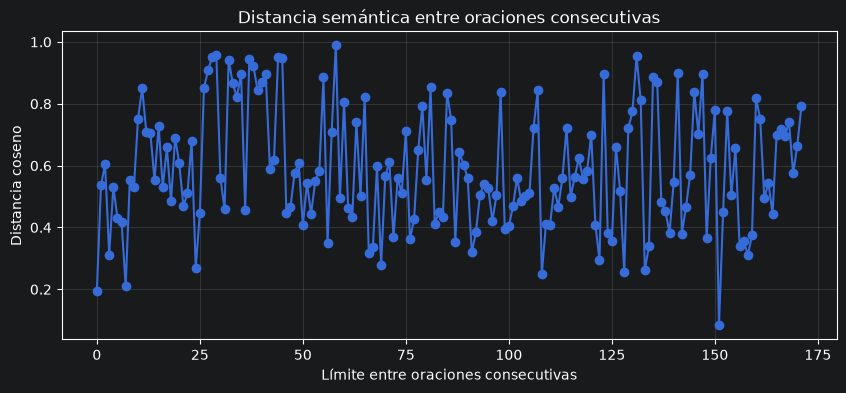

In [19]:
if len(inspect_distances) > 0:
    plt.figure(figsize=(10, 4))
    plt.plot(np.arange(len(inspect_distances)), inspect_distances, marker="o")
    plt.xlabel("Límite entre oraciones consecutivas")
    plt.ylabel("Distancia coseno")
    plt.title("Distancia semántica entre oraciones consecutivas")
    plt.grid(alpha=0.25)
    plt.show()

## 12. Construcción de los corpus e indexación

Ahora construimos todos los chunks para cada estrategia y medimos el costo de preparación.

Separamos el tiempo de **chunking** y **indexación**. También contamos los tokens que procesa el modelo de embeddings. En `Semantic breakpoint`, la decisión de corte necesita embeddings de oraciones antes de construir los chunks; por eso esa etapa aparece como consumo adicional.


In [20]:
def build_corpus(strategy_name: str):
    chunks = []

    start_chunking = time.perf_counter()

    for doc_id in documents.keys():
        if strategy_name == "Fixed-size":
            current = fixed_size_chunker(doc_id)

        elif strategy_name == "Semantic breakpoint":
            current, _ = semantic_breakpoint_chunker(doc_id)

        elif strategy_name == "Structure-aware":
            current = structure_aware_chunker(doc_id)

        else:
            raise ValueError(strategy_name)

        chunks.extend(current)

    chunking_seconds = time.perf_counter() - start_chunking

    chunk_texts = [c.text for c in chunks]
    chunk_token_profile = token_stats(chunk_texts)

    start_indexing = time.perf_counter()
    chunk_embeddings = embed_texts(chunk_texts)
    indexing_seconds = time.perf_counter() - start_indexing

    semantic_raw_tokens = (
        sentence_token_profile["raw_tokens"]
        if strategy_name == "Semantic breakpoint"
        else 0
    )
    semantic_effective_tokens = (
        sentence_token_profile["effective_tokens"]
        if strategy_name == "Semantic breakpoint"
        else 0
    )

    profile = {
        "strategy": strategy_name,
        "chunking_seconds": chunking_seconds,
        "indexing_seconds": indexing_seconds,
        "total_preprocess_seconds": chunking_seconds + indexing_seconds,
        "n_chunks": len(chunks),
        "avg_sentences_per_chunk": (
            float(np.mean([len(c.sentence_ids) for c in chunks]))
            if chunks else 0.0
        ),
        "chunk_index_raw_tokens": chunk_token_profile["raw_tokens"],
        "chunk_index_effective_tokens": chunk_token_profile["effective_tokens"],
        "semantic_decision_raw_tokens": semantic_raw_tokens,
        "semantic_decision_effective_tokens": semantic_effective_tokens,
        "total_embedding_effective_tokens": (
            chunk_token_profile["effective_tokens"] + semantic_effective_tokens
        ),
        "avg_raw_tokens_per_chunk": chunk_token_profile["avg_raw_tokens"],
        "avg_effective_tokens_per_chunk": chunk_token_profile["avg_effective_tokens"],
        "p95_raw_tokens_per_chunk": chunk_token_profile["p95_raw_tokens"],
        "p95_effective_tokens_per_chunk": chunk_token_profile["p95_effective_tokens"],
        "truncated_chunks": chunk_token_profile["truncated_items"],
    }

    return chunks, chunk_embeddings, profile


In [21]:
STRATEGIES = [
    "Fixed-size",
    "Semantic breakpoint",
    "Structure-aware",
]

experiment = {}

for strategy_name in STRATEGIES:
    print("Construyendo:", strategy_name)

    chunks, embeddings, profile = build_corpus(strategy_name)

    experiment[strategy_name] = {
        "chunks": chunks,
        "embeddings": embeddings,
        "profile": profile,
    }

    print(profile)

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (508 > 384). Running this sequence through the model will result in indexing errors


Construyendo: Fixed-size
{'strategy': 'Fixed-size', 'chunking_seconds': 0.027890800000022864, 'indexing_seconds': 1019.7075910000003, 'total_preprocess_seconds': 1019.7354818000003, 'n_chunks': 3110, 'avg_sentences_per_chunk': 5.923472668810289, 'chunk_index_raw_tokens': 575659, 'chunk_index_effective_tokens': 572404, 'semantic_decision_raw_tokens': 0, 'semantic_decision_effective_tokens': 0, 'total_embedding_effective_tokens': 572404, 'avg_raw_tokens_per_chunk': 185.09935691318327, 'avg_effective_tokens_per_chunk': 184.05273311897105, 'p95_raw_tokens_per_chunk': 295.0, 'p95_effective_tokens_per_chunk': 295.0, 'truncated_chunks': 36}
Construyendo: Semantic breakpoint
{'strategy': 'Semantic breakpoint', 'chunking_seconds': 945.4994717999998, 'indexing_seconds': 266.1428659999983, 'total_preprocess_seconds': 1211.6423377999981, 'n_chunks': 800, 'avg_sentences_per_chunk': 19.265, 'chunk_index_raw_tokens': 478887, 'chunk_index_effective_tokens': 202921, 'semantic_decision_raw_tokens': 5081

## 13. Retrieval

Para una pregunta:

1. calculamos su embedding;
2. medimos similitud coseno contra todos los chunks;
3. ordenamos de mayor a menor similitud;
4. tomamos los `top-k`.

Todos los chunkers usan el mismo procedimiento de retrieval.

In [22]:
def retrieve_top_k(
    question: str,
    chunks: List[Chunk],
    chunk_embeddings: np.ndarray,
    k: int,
):
    query_embedding = embed_texts([question])[0]
    scores = chunk_embeddings @ query_embedding
    order = np.argsort(-scores)[:k]

    return [
        (chunks[idx], float(scores[idx]))
        for idx in order
    ]

### 13.1 Ver una pregunta real

Aquí podemos comparar qué recupera cada estrategia para la misma pregunta de QASPER.

In [23]:
if len(qa_df) > 0:
    q = qa_df.iloc[0]

    print("Pregunta:")
    print(q["question"])

    print("\nDocumento correcto:")
    print(documents[q["doc_id"]]["title"])

    print("\nEvidence sentence IDs:")
    print(q["evidence_sentence_ids"])

    for strategy_name in STRATEGIES:
        print("\n" + "=" * 90)
        print(strategy_name)

        output = experiment[strategy_name]
        retrieved = retrieve_top_k(
            q["question"],
            output["chunks"],
            output["embeddings"],
            k=3,
        )

        for rank, (chunk, score) in enumerate(retrieved, start=1):
            print(
                f"Top {rank} | score={score:.3f} | "
                f"doc={chunk.doc_id} | sentences={chunk.sentence_ids}"
            )
            print(chunk.text[:500])
            print()

Pregunta:
What evaluation metrics are looked at for classification tasks?

Documento correcto:
Mining Supervisor Evaluation and Peer Feedback in Performance Appraisals

Evidence sentence IDs:
[72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 117, 118, 119]

Fixed-size
Top 1 | score=0.594 | doc=1906.01081 | sentences=[90, 91, 92, 93, 94, 95]
Commonly used metrics which only rely on the reference (BLEU, ROUGE, METEOR, CIDEr) have only weak correlations with human judgments. In the hyperparams category, these are often negative, implying that tuning models based on these may lead to selecting worse models. BLEU performs the best among these, and adding n-grams from the table as references improves this further (BLEU-T). Among the extractive evaluation metrics, CS, which also only relies on the reference, has poor correlation in the hy

Top 2 | score=0.516 | doc=2001.03131 | sentences=[145, 146, 147]
The measures used for evaluation are accuracy, precision, recall, and f1-score. We observed that RK

## 14. Métricas de Evidence Retrieval

Para cada pregunta conocemos las oraciones de evidencia mapeadas dentro de su documento.

A partir de los chunks recuperados construimos un conjunto de pares:

`(doc_id, sentence_id)`

Así podemos distinguir una oración de otro documento aunque tenga el mismo número de índice.

Calculamos:

\[
Precision = \frac{|R \cap G|}{|R|}
\]

\[
Recall = \frac{|R \cap G|}{|G|}
\]

\[
F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}
\]

donde:

- `R` = oraciones recuperadas;
- `G` = oraciones de evidencia esperadas.

In [24]:
def precision_recall_f1(retrieved: set, gold: set):
    intersection = len(retrieved & gold)

    precision = intersection / len(retrieved) if retrieved else 0.0
    recall = intersection / len(gold) if gold else 0.0

    if precision + recall == 0:
        f1 = 0.0
    else:
        f1 = 2 * precision * recall / (precision + recall)

    return precision, recall, f1


def evaluate_evidence_retrieval(
    chunks: List[Chunk],
    chunk_embeddings: np.ndarray,
    questions: pd.DataFrame,
    k_values=TOP_K_VALUES,
):
    rows = []

    for _, q in questions.iterrows():
        gold = {
            (q["doc_id"], sid)
            for sid in q["evidence_sentence_ids"]
        }

        for k in k_values:
            retrieved_chunks = retrieve_top_k(
                q["question"],
                chunks,
                chunk_embeddings,
                k=k,
            )

            retrieved_sentences = set()

            for chunk, _ in retrieved_chunks:
                for sid in chunk.sentence_ids:
                    retrieved_sentences.add((chunk.doc_id, sid))

            precision, recall, f1 = precision_recall_f1(
                retrieved_sentences,
                gold,
            )

            rows.append({
                "question_id": q["question_id"],
                "doc_id": q["doc_id"],
                "k": k,
                "precision": precision,
                "recall": recall,
                "f1": f1,
            })

    return pd.DataFrame(rows)

## 15. Ejecutar evaluación

Esta es la parte que produce las métricas principales del paper.

En modo demo son **resultados preliminares**. Para la versión final del documento se debe repetir con `DEMO_MODE=False` y guardar la configuración exacta.

In [25]:
all_scores = []

for strategy_name in STRATEGIES:
    output = experiment[strategy_name]

    scores = evaluate_evidence_retrieval(
        output["chunks"],
        output["embeddings"],
        qa_df,
    )

    scores["strategy"] = strategy_name
    all_scores.append(scores)

scores_df = pd.concat(all_scores, ignore_index=True)

display(scores_df.head())

,question_id,doc_id,k,precision,recall,f1,strategy
0,fb3d30d59ed49e87f63d3735b876d45c4c6b8939,1712.00991,1,0.0,0.0,0.0,Fixed-size
1,fb3d30d59ed49e87f63d3735b876d45c4c6b8939,1712.00991,3,0.0,0.0,0.0,Fixed-size
2,fb3d30d59ed49e87f63d3735b876d45c4c6b8939,1712.00991,5,0.0,0.0,0.0,Fixed-size
3,fb3d30d59ed49e87f63d3735b876d45c4c6b8939,1712.00991,10,0.0,0.0,0.0,Fixed-size
4,1f085b9bb7bfd0d6c8cba1a9d73f08fcf2da7590,1810.08699,1,0.0,0.0,0.0,Fixed-size


In [26]:
summary = (
    scores_df
    .groupby(["strategy", "k"])[["precision", "recall", "f1"]]
    .mean()
    .reset_index()
)

display(
    summary.style.format({
        "precision": "{:.4f}",
        "recall": "{:.4f}",
        "f1": "{:.4f}",
    })
)

,strategy,k,precision,recall,f1
0,Fixed-size,1,0.0700,0.0357,0.0425
1,Fixed-size,3,0.0431,0.0745,0.0486
2,Fixed-size,5,0.0388,0.1108,0.0515
3,Fixed-size,10,0.0301,0.1554,0.0471
4,Semantic breakpoint,1,0.0286,0.0406,0.0280
5,Semantic breakpoint,3,0.0224,0.1098,0.0344
6,Semantic breakpoint,5,0.0175,0.1629,0.0302
7,Semantic breakpoint,10,0.0136,0.2245,0.0248
8,Structure-aware,1,0.0800,0.0246,0.0343
9,Structure-aware,3,0.0587,0.0472,0.0469


## 16. Costo computacional

Juntamos tiempo, cantidad de chunks y tokens procesados para comparar cuánto trabajo exige cada estrategia bajo la misma ejecución.


In [27]:
cost_table = pd.DataFrame([
    experiment[name]["profile"]
    for name in STRATEGIES
])

display(
    cost_table.style.format({
        "chunking_seconds": "{:.3f}",
        "indexing_seconds": "{:.3f}",
        "total_preprocess_seconds": "{:.3f}",
        "avg_sentences_per_chunk": "{:.2f}",
        "avg_raw_tokens_per_chunk": "{:.1f}",
        "p95_raw_tokens_per_chunk": "{:.1f}",
    })
)


,strategy,chunking_seconds,indexing_seconds,total_preprocess_seconds,n_chunks,avg_sentences_per_chunk,chunk_index_raw_tokens,chunk_index_effective_tokens,semantic_decision_raw_tokens,semantic_decision_effective_tokens,total_embedding_effective_tokens,avg_raw_tokens_per_chunk,avg_effective_tokens_per_chunk,p95_raw_tokens_per_chunk,p95_effective_tokens_per_chunk,truncated_chunks
0,Fixed-size,0.028,1019.708,1019.735,3110,5.92,575659,572404,0,0,572404,185.1,184.052733,295.0,295.000000,36
1,Semantic breakpoint,945.499,266.143,1211.642,800,19.27,478887,202921,508111,508111,711032,598.6,253.651250,2049.2,384.000000,385
2,Structure-aware,0.100,860.349,860.449,4672,3.34,492383,492023,0,0,492023,105.4,105.313142,231.0,231.000000,7


## 17. Resultado central: calidad vs. costo

Para el paper podemos usar F1@5 como punto principal de comparación y contrastarlo con el tiempo total de preprocesamiento.

In [28]:
f1_at_5 = (
    summary[summary["k"] == 5]
    [["strategy", "f1"]]
    .merge(
        cost_table[
            ["strategy", "total_preprocess_seconds", "n_chunks"]
        ],
        on="strategy",
        how="left",
    )
)

display(f1_at_5)

,strategy,f1,total_preprocess_seconds,n_chunks
0,Fixed-size,0.051483,1019.735482,3110
1,Semantic breakpoint,0.030160,1211.642338,800
2,Structure-aware,0.050550,860.448826,4672


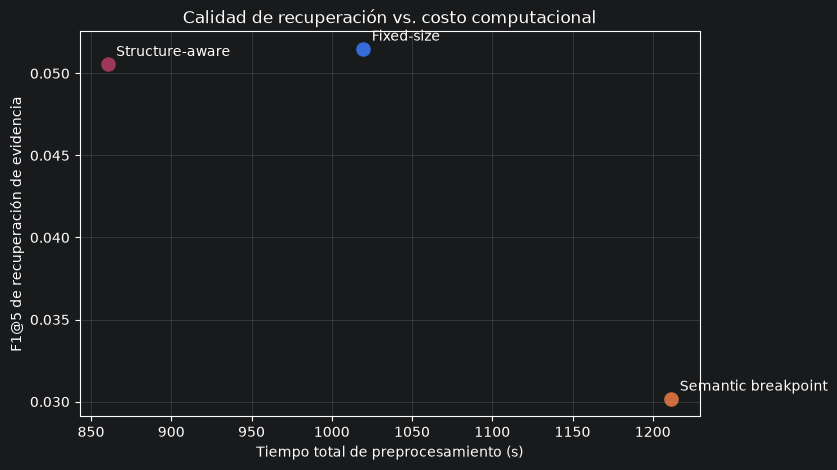

In [29]:
plt.figure(figsize=(8, 5))

for _, row in f1_at_5.iterrows():
    plt.scatter(
        row["total_preprocess_seconds"],
        row["f1"],
        s=90,
    )

    plt.annotate(
        row["strategy"],
        (row["total_preprocess_seconds"], row["f1"]),
        xytext=(6, 6),
        textcoords="offset points",
    )

plt.xlabel("Tiempo total de preprocesamiento (s)")
plt.ylabel("F1@5 de recuperación de evidencia")
plt.title("Calidad de recuperación vs. costo computacional")
plt.grid(alpha=0.25)
plt.show()

## 18. Resultados por pregunta

Si vemos resultados extraños en el promedio, aquí podemos revisar cuáles preguntas favorecen o perjudican a cada estrategia.

In [30]:
comparison_per_question = (
    scores_df[scores_df["k"] == 5]
    .pivot_table(
        index=["question_id", "doc_id"],
        columns="strategy",
        values="f1",
    )
    .reset_index()
)

display(comparison_per_question.head(20))

strategy,question_id,doc_id,Fixed-size,Semantic breakpoint,Structure-aware
0,005cca3c8ab6c3a166e315547a2259020f318ffb,2003.04642,0.000000,0.031008,0.000000
1,009ce6f2bea67e7df911b3f93443b23467c9f4a1,1909.09587,0.000000,0.000000,0.000000
2,00c57e45ac6afbdfa67350a57e81b4fad0ed2885,1701.08229,0.000000,0.000000,0.000000
3,022c365a14fdec406c7a945a1a18e7e79df37f08,1909.07575,0.000000,0.000000,0.000000
4,03c967763e51ef2537793db7902e2c9c17e43e95,1909.02304,0.000000,0.000000,0.000000
5,044f922604b4b3f42ae381419fd5cd5624fa0637,1710.03348,0.047619,0.090090,0.057143
6,0689904db9b00a814e3109fb1698086370a28fa2,1811.05711,0.000000,0.000000,0.000000
7,0752d71a0a1f73b3482a888313622ce9e9870d6e,1708.01464,0.000000,0.000000,0.000000
8,07d15501a599bae7eb4a9ead63e9df3d55b3dc35,1612.06685,0.162162,0.067797,0.000000
9,0810b43404686ddfe4ca84783477ae300fdd2ea4,1910.10781,0.333333,0.057971,0.313725


## 19. Exportar resultados

Guardamos CSV para que las tablas del paper salgan directamente del experimento y no tengan que copiarse manualmente desde la pantalla.

In [31]:
def find_project_root():
    start = Path.cwd().resolve()
    candidates = [start, *start.parents]

    for candidate in candidates:
        if (candidate / "index.html").exists() and (candidate / "assets" / "js").is_dir():
            return candidate

    try:
        for candidate in start.iterdir():
            if (
                candidate.is_dir()
                and (candidate / "index.html").exists()
                and (candidate / "assets" / "js").is_dir()
            ):
                return candidate
    except OSError:
        pass

    return None


PROJECT_ROOT = find_project_root()
RUNNING_IN_COLAB = "google.colab" in sys.modules

if PROJECT_ROOT is not None:
    RESULTS_DIR = PROJECT_ROOT / "data" / "run_artifacts"
    ZIP_BASE = PROJECT_ROOT / "resultados_chunking_para_web"
else:
    OUTPUT_ROOT = Path("/content") if RUNNING_IN_COLAB else Path.cwd()
    RESULTS_DIR = OUTPUT_ROOT / "resultados_chunking_qasper"
    ZIP_BASE = OUTPUT_ROOT / "resultados_chunking_para_web"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

summary.to_csv(RESULTS_DIR / "metricas_resumen.csv", index=False)
cost_table.to_csv(RESULTS_DIR / "costos.csv", index=False)
scores_df.to_csv(RESULTS_DIR / "metricas_por_pregunta.csv", index=False)
f1_at_5.to_csv(RESULTS_DIR / "calidad_vs_costo.csv", index=False)
summary.to_csv(RESULTS_DIR / "metrics.csv", index=False)

metadata = {
    "seed": SEED,
    "demo_mode": DEMO_MODE,
    "split": SPLIT,
    "n_docs": len(documents),
    "n_questions": len(qa_df),
    "embedding_model": MODEL_NAME,
    "max_sequence_length": MAX_SEQUENCE_LENGTH,
    "fixed_chunk_size": FIXED_CHUNK_SIZE,
    "fixed_overlap": FIXED_OVERLAP,
    "semantic_target_chunks": SEMANTIC_TARGET_CHUNKS,
    "structure_max_sentences": STRUCTURE_MAX_SENTENCES,
    "structure_overlap": STRUCTURE_OVERLAP,
    "top_k_values": TOP_K_VALUES,
}

with open(RESULTS_DIR / "configuracion.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

question_embeddings = (
    embed_texts(qa_df["question"].tolist())
    if len(qa_df)
    else np.empty((0, embedding_dimension()))
)

strategy_rows = []

for strategy_name in STRATEGIES:
    output = experiment[strategy_name]
    chunk_texts = [chunk.text for chunk in output["chunks"]]
    chunk_token_profile = token_stats(chunk_texts)
    chunk_tokens = chunk_token_profile["effective_lengths"]
    context_token_totals = []

    for question_embedding in question_embeddings:
        scores = output["embeddings"] @ question_embedding
        top_indices = np.argsort(-scores)[:min(5, len(scores))]
        context_token_totals.append(
            int(sum(chunk_tokens[idx] for idx in top_indices))
        )

    strategy_rows.append({
        **output["profile"],
        "avg_retrieved_context_tokens_at_5": (
            float(np.mean(context_token_totals))
            if context_token_totals else 0.0
        ),
    })

example_doc_id = INSPECT_DOC_ID
example_doc = documents[example_doc_id]
example_strategies = {}

for strategy_name in STRATEGIES:
    selected = [
        chunk
        for chunk in experiment[strategy_name]["chunks"]
        if chunk.doc_id == example_doc_id
    ]

    example_strategies[strategy_name] = [
        {
            "chunk": index + 1,
            "sentence_count": len(chunk.sentence_ids),
            "sentence_start": int(chunk.sentence_ids[0]) if chunk.sentence_ids else None,
            "sentence_end": int(chunk.sentence_ids[-1]) if chunk.sentence_ids else None,
            "text": chunk.text[:520],
        }
        for index, chunk in enumerate(selected[:6])
    ]

payload = {
    "schema_version": 4,
    "source": {
        "mode": "notebook_run",
        "basis": "Experimento_Paper_Chunking_QASPER.ipynb",
        "dataset": "QASPER",
        "generated_at": time.strftime("%Y-%m-%dT%H:%M:%S%z"),
    },
    "run": metadata,
    "metrics": summary.to_dict(orient="records"),
    "strategies": strategy_rows,
    "example": {
        "title": example_doc["title"],
        "strategies": example_strategies,
    },
}

with open(RESULTS_DIR / "results.json", "w", encoding="utf-8") as f:
    json.dump(payload, f, indent=2, ensure_ascii=False)

with open(RESULTS_DIR / "results-data.js", "w", encoding="utf-8") as f:
    f.write(
        "window.RAG_RESULTS = "
        + json.dumps(payload, ensure_ascii=False, separators=(",", ":"))
        + ";\n"
    )

if PROJECT_ROOT is not None:
    web_json = PROJECT_ROOT / "data" / "results.json"
    web_js = PROJECT_ROOT / "assets" / "js" / "results-data.js"
    web_metrics = PROJECT_ROOT / "data" / "metrics.csv"

    web_json.parent.mkdir(parents=True, exist_ok=True)
    web_js.parent.mkdir(parents=True, exist_ok=True)

    shutil.copy2(RESULTS_DIR / "results.json", web_json)
    shutil.copy2(RESULTS_DIR / "results-data.js", web_js)
    shutil.copy2(RESULTS_DIR / "metrics.csv", web_metrics)

ZIP_PATH = shutil.make_archive(
    str(ZIP_BASE),
    "zip",
    RESULTS_DIR,
)

print("Resultados:", RESULTS_DIR)
print("Paquete:", ZIP_PATH)
if PROJECT_ROOT is not None:
    print("Landing actualizada:", PROJECT_ROOT / "index.html")


Resultados: C:\Users\renzi\PycharmProjects\chunking_rag_interactivo\data\run_artifacts
Paquete: C:\Users\renzi\PycharmProjects\chunking_rag_interactivo\resultados_chunking_para_web.zip
Landing actualizada: C:\Users\renzi\PycharmProjects\chunking_rag_interactivo\index.html


## 20. Resultado exportado

La carpeta `resultados_chunking_qasper` conserva las tablas del experimento. El archivo `resultados_chunking_para_web.zip` contiene los datos que consume la landing interactiva.
